In [ ]:
import numpy as np
from multiprocessing import Pool
from multiprocessing import get_context
from functools import partial
from tqdm import tqdm

import OscTools.param_scan as param_scan
import OscTools.mini_tools as mini
from OscTools import apps
from importlib.resources import files

In [11]:
Weight_nue_flux = apps.reweight_MC_to_nue_flux(
            param_scan.Etrue_nue, param_scan.Weight_nue, mode="fhc"
        )

MC_nue_bkg_intrinsic = np.dot(
                param_scan.fast_histogram(
                    param_scan.Etrue_nue, bins=param_scan.e_prod_e_int_bins, weights=Weight_nue_flux
                )[0],
                apps.migration_matrix_official_bins_nue_11bins,
            )

In [12]:
# next we digitize pi0 misid bkg, add 50% on top of it.
m_top = np.array([4.7194, 3.3466, 2.3535, 1.3198, 0.9639, 0.4446, 0.3589, 0.2728, 0.1453, 0.0844])
m_bot = np.array([1.7350, 1.6645, 1.3633, 0.8044, 0.5163, 0.2004, 0.1283, 0.0829, 0.0367, 0.0165])
mid_pi0 = (m_top - m_bot)[:4]
# append 7 0s to the end
for i in range(7):
    mid_pi0 = np.append(mid_pi0, 0)
print(mid_pi0)

[2.9844 1.6821 0.9902 0.5154 0.     0.     0.     0.     0.     0.
 0.    ]


(0.0, 8.0)

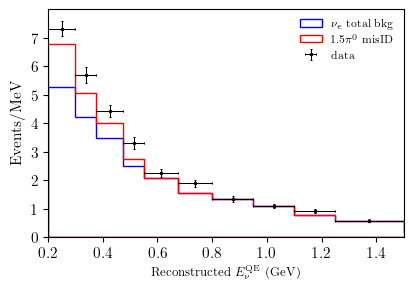

In [47]:
import OscTools.plot_tools as pt
fig, ax = pt.std_fig(figsize=(4.5,3))
bins = param_scan.MB_Ereco_official_bins
bin_w = np.diff(bins)
bin_c = bins[:-1] + bin_w/2
# MiniBooNE 
TOTAL_RATE = False
if TOTAL_RATE:
    units= 1
    ax.set_ylabel(r"Events")
else:
    units = 1/mini.bin_width
    ax.set_ylabel(r"Events/MeV")

year = 2020
nue_data = np.genfromtxt(
    files(f"OscTools.include.MB_data_release_{year}.combined").joinpath("miniboone_nuedata_lowe.txt").open()
)
nue_tot_bkg = np.genfromtxt(
            files(f"OscTools.include.MB_data_release_{year}.combined").joinpath("miniboone_nuebgr_lowe.txt").open()
        )
nue_bkg_midID = nue_tot_bkg - MC_nue_bkg_intrinsic
# plot data
pt.data_plot(ax, 
        X=bin_c,
        Y=(nue_data)*units, 
        xerr=bin_w/2, 
        yerr=np.sqrt(nue_data)*units,
        zorder=3)
ax.hist(bins[:-1],
        bins=bins,
        weights=(nue_tot_bkg)*units,
        #weights=(nue_bkg_midID)*units,
        edgecolor='blue',
        facecolor='None',
        lw=1.25,
        label=r'$\nu_e$ total bkg',
        histtype='stepfilled',
        zorder=1.5)

# Add 50% pi0 misID under 550MeV
ax.hist(bins[:-1],
        bins=bins,
        weights=(nue_tot_bkg)*units + 0.5*mid_pi0,
        #weights=(nue_bkg_midID)*units,
        edgecolor='red',
        facecolor='None',
        lw=1.25,
        label=r'1.5$\pi^0$ misID',
        histtype='stepfilled',
        zorder=1.5)

ax.set_xlabel(r"Reconstructed $E_\nu^{\rm QE}$ (GeV)", fontsize=9, labelpad=2.5)
ax.legend(fontsize=8, loc='upper right')
ax.set_xticks([0.2,0.4,0.6,0.8,1,1.2,1.4])
ax.set_yticks([0,1,2,3,4,5,6,7])
ax.set_xlim(0.2,1.5)
ax.set_ylim(0,8)

Now do a MiniBooNE fit

In [14]:
mid_pi0_tot = mid_pi0/units
print(mid_pi0_tot)

[298.44   126.1575  99.02    38.655    0.       0.       0.       0.
   0.       0.       0.    ]


In [49]:
def return_miniboone_chi2(theta,
    oscillations=True,
    decay=False,
    decouple_decay=False,
    disappearance=False,
    energy_degradation=False,
    use_numu_MC=False,
    undo_numu_normalization=False,
    n_replications=10,
    include_antineutrinos=False,
    helicity="conserving",):

    rates_dic = param_scan.get_nue_rates(
    theta,
    oscillations=oscillations,
    decay=decay,
    decouple_decay=decouple_decay,
    disappearance=disappearance,
    energy_degradation=energy_degradation,
    use_numu_MC=use_numu_MC,
    undo_numu_normalization=undo_numu_normalization,
    n_replications=n_replications,
    include_antineutrinos=include_antineutrinos,
    helicity=helicity,
    )

    MB_chi2 = mini.chi2_MiniBooNE_combined(
    MC_nue_app=rates_dic["MC_nue_app"],
    MC_nuebar_app=rates_dic["MC_nuebar_app"],
    MC_nue_dis=rates_dic["MC_nue_bkg_total_w_dis"]+0.68*mid_pi0_tot,
    #MC_nue_dis=rates_dic["MC_nue_bkg_total_w_dis"],
    MC_numu_dis=rates_dic["MC_numu_bkg_total_w_dis"],
    MC_nuebar_dis=rates_dic["MC_nuebar_bkg_total_w_dis"],
    MC_numubar_dis=rates_dic["MC_numubar_bkg_total_w_dis"],
    year="2020")

    return [
        theta["g"],
        theta["m4"],
        theta["Ue4Sq"],
        theta["Um4Sq"],
        MB_chi2,
    ]


def run_scan_mini_only(
    kwargs,
    filename,
    Npoints=10,
    path_results="fit_data/",
    sin2theta_scan=False,
):
    # Range of mixings scanned
    dm_Vec = np.geomspace(np.sqrt(1e-1), np.sqrt(100), Npoints)

    if sin2theta_scan:
        s2thetaSq = np.geomspace(1e-5, 0.1, Npoints)
        Umu4Sq = 0.5
        # Cartesian product of grid -- already imposes unitarity and pertubatirbity of g
        paramlist = param_scan.create_grid_of_params_sin2theta(
            g=1e-10, m4=dm_Vec, sin2thetaSq=s2thetaSq, Um4Sq=Umu4Sq
        )

    else:
        Ue4Sq = np.geomspace(1e-3, 0.5, Npoints)
        Umu4Sq = np.geomspace(1e-3, 0.5, Npoints)
        # Cartesian product of grid -- already imposes unitarity and pertubatirbity of g
        paramlist = param_scan.create_grid_of_params(
            g=1e-10, m4=dm_Vec, Ue4Sq=Ue4Sq, Um4Sq=Umu4Sq
        )
    func_scan = partial(return_miniboone_chi2, **kwargs)

    with get_context("fork").Pool() as pool:
        # res = pool.map(func_scan, paramlist)
        res = np.array(
            list(tqdm(pool.imap(func_scan, paramlist), total=len(paramlist)))
        )

    param_scan.write_pickle(f"{path_results}/{filename}", res)

    return res

In [50]:
kwargs_common = {
    'oscillations': True, 
    'decay': False, 
    'decouple_decay': True, 
    'energy_degradation': False, 
    'include_antineutrinos': True, 
    'n_replications': 1}

kwargs_std_numu_MC_keep_numu_norm = {
    'disappearance': True, 
    'use_numu_MC': True,
    'undo_numu_normalization': False,
    **kwargs_common}

In [51]:

fraction = 0.68
n = 25
_ = run_scan_mini_only(kwargs_std_numu_MC_keep_numu_norm, f'TZ_Mini_misid{fraction}{n}', sin2theta_scan=False, Npoints=n)

  9%|▉         | 1411/15600 [06:57<1:09:55,  3.38it/s]


KeyboardInterrupt: 

Draw contours

In [ ]:
def load_scan_data(filename):
    data = param_scan.pickle_read(filename)
    
    data_dic = {}
    data_dic['Ue4SQR'] = data[:,2]
    data_dic['Umu4SQR'] = data[:,3]
    s2t = 4*data_dic['Ue4SQR']*data_dic['Umu4SQR']
    data_dic['sin2theta'] = np.round(s2t, decimals=6)
    data_dic['dm4SQR'] = data[:,1]**2
    
    data_dic['MiniApp_chi2'] =  data[:,4]
    data_dic['MiniApp_deltachi2'] = data_dic['MiniApp_chi2'] - np.min(data_dic['MiniApp_chi2'])

    return data_dic

data_dic = load_scan_data('fit_data/TZ_Mini_misid25.pkl')

def profile_for_sin2theta(data_dic, **kwargs):
    dic_prof = {}
    # Profile each chi2
    for key in data_dic.keys():
        if not (key == 'sin2theta' or key == 'dm4SQR'):
            dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof[key] = param_scan.profile_in_plane_numba(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic[key], **kwargs)
    
    return dic_prof

# Profile to get sin2theta_emu
kwargs={'x_max': 1}
profiled_dic = profile_for_sin2theta(data_dic, **kwargs)

print((data_dic['MiniApp_chi2']))



[  43.39538867   43.39454728   43.39309642 ... 3889.77082732 3936.93209387
 3882.48135033]


In [33]:
print(np.min(data_dic['MiniApp_chi2']))

24.98976738635544


In [34]:
print(np.min(data_dic_old['MiniApp_chi2']))

36.274238739277195


In [31]:
data_dic_old = load_scan_data('fit_data/BooNE_KJK_fullosc_3D_v2_half.pkl')
profiled_dic_old = profile_for_sin2theta(data_dic_old, x_max=1)

[np.float64(2.295748928898636), np.float64(6.180074306244173), np.float64(11.829158081900795), np.float64(19.333908611934685)]
bestfit: 0.020565715872313903 0.23713737056616552


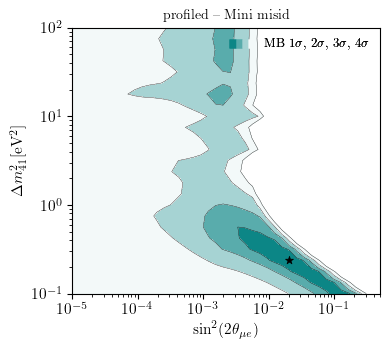

In [37]:
def make_sin2thetaemu_plot(ax1, dic, name='default', asimov=False, cmap_color='steelblue', n_sigmas=4, cmin=0.05, cmax=0.95,):
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel(r"$\sin^2(2\theta_{\mu e})$", fontproperties=pt.font)
    ax1.set_ylabel(r'$\Delta m_{41}^2 [\mathrm{eV^2}]$', fontproperties=pt.font)
    ax1.set_title(fr"profiled -- " + name.replace('_',' '), fontsize=10)
    # ax1.set_xlim(1e-4,0.2)

    kwargs_interp = {'fine_gridx': len(np.unique(dic['sin2theta'])),  
                    'fine_gridy': len(np.unique(dic['dm4SQR'])), 
                    'logx':True, 
                    'logy':True}
    # X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MiniApp_deltachi2'], **kwargs_interp)
    # cs = ax1.contourf(X,Y,Z, levels=[0, 2.3, 6.18, 11.83, 19.33], colors=['tomato','darkorange','orange','peachpuff'], zorder=1, alpha=0.75)
    # cs = ax1.contour(X,Y,Z, levels=[2.3, 6.18, 11.83, 19.33], colors=['black','black','black','black'], linewidths=0.25, zorder=1, alpha=0.75)
    # # ax1.scatter(app_dic['sin2theta'], app_dic['dm4SQR'])
    
    colors = pt.get_cmap_colors(cmap_color, n_sigmas, cmin=cmin, cmax=cmax)
    X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MiniApp_deltachi2'], **kwargs_interp)
    cs = ax1.contourf(X,Y,Z, levels=np.insert(pt.get_chi2vals_w_nsigmas(n_sigmas, 2), 0, 0), colors=colors, zorder=1, alpha=1)
    print(pt.get_chi2vals_w_nsigmas(n_sigmas, 2))
    cs = ax1.contour(X,Y,Z, levels=pt.get_chi2vals_w_nsigmas(n_sigmas, 2), colors=['black'], linewidths=0.25, zorder=1, alpha=1)
    # ax1.scatter(dic['Umu4SQR'], dic['dm4SQR'], c=np.log10(dic['MiniApp_chi2']-np.min(dic['MiniApp_chi2'])),)
    ax1.scatter(X.flatten()[np.nanargmin(Z)], Y.flatten()[np.nanargmin(Z)], marker='*', facecolor='black', edgecolor='black', lw=0.5, zorder=10)
    print('bestfit:', X.flatten()[np.nanargmin(Z)], Y.flatten()[np.nanargmin(Z)])
    ax1.set_ylim(1e-1, 1e2)
    ax1.set_xlim(1e-5, 0.5)
    
    # ------ get the legend-entries that are already attached to the axis
    h, l = ax1.get_legend_handles_labels()
    mb_label = 'MB '+', '.join([fr'${i+1} \sigma$' for i in range(n_sigmas)])
    leg1 = ax1.legend([pt.MulticolorPatch(colors)], [mb_label], loc='upper right', fontsize=9, handler_map={pt.MulticolorPatch: pt.MulticolorPatchHandler()})
    ax1.add_artist(leg1)
    # ax1.add_artist(leg2)

    return ax1
    # fig.savefig(f"{micro.path_plots}/MH_full_osc_sin2thetaemuSQR_profiled.pdf", bbox_inches='tight', dpi=300)
    # fig.savefig(f"{micro.path_plots}/MH_full_osc_sin2thetaemuSQR_profiled_{name}.pdf", bbox_inches='tight', dpi=300)

f = [0.18, 0.16, 0.77, 0.76]
fig, ax = pt.std_fig(figsize=(4, 3.5), ax_form=f)
# fig, ax = make_sin2thetaemu_plot_comparison(dic_numu_MC_keep_numu_norm, name='numu_MC_keep_numu_norm')

ax = make_sin2thetaemu_plot(ax, profiled_dic, name='Mini_misid', asimov=False, cmap_color='teal', n_sigmas=4, cmin=0.05, cmax=0.95)


[np.float64(2.295748928898636), np.float64(6.180074306244173), np.float64(11.829158081900795), np.float64(19.333908611934685)]
bestfit: 0.06224109608438763 0.16070528182616392


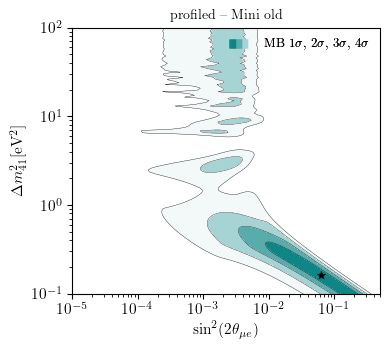

In [38]:
f = [0.18, 0.16, 0.77, 0.76]
fig, ax = pt.std_fig(figsize=(4, 3.5), ax_form=f)
ax = make_sin2thetaemu_plot(ax, profiled_dic_old, name='Mini_old', asimov=False, cmap_color='teal', n_sigmas=4, cmin=0.05, cmax=0.95)

In [60]:
import matplotlib.pyplot as plt
from scipy.stats import chi2
import MicroTools as micro
levels_sigmas_2dof = [chi2.ppf(0.682689492137086, 2), chi2.ppf(0.954499736103642, 2), chi2.ppf(0.997300203936740, 2), chi2.ppf(0.999936657516334, 2)]
levels_sigmas_3dof = [chi2.ppf(0.682689492137086, 3), chi2.ppf(0.954499736103642, 3), chi2.ppf(0.997300203936740, 3), chi2.ppf(0.999936657516334, 3)]
level_95CL_2dof = [chi2.ppf(0.95, 2)]
level_95CL_3dof = [chi2.ppf(0.95, 3)]

labels_slices = [r'$g_\varphi$',r'$\Delta m_{41}^2 [\mathrm{eV^2}]$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]
string_slices = [r'$g_\varphi$',r'$\Delta m_{41}^2$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]
def get_var(data, i):
    if i == 1:
        return data[:,1]**2
    return data[:,i]

def plot_all_slices(filename, xi=2, yi=3, zi=1, global_deltachi2=False):
    data_mic = param_scan.pickle_read(f"fit_data/{filename}.pkl")   
    data = param_scan.pickle_read(f"fit_data/BooNE_KJK_fullosc_3D_v2_half.pkl")
    MiniApp_chi2, MicroApp_chi2, MicroApp_Asimov_chi2 = data_mic[:,4], data[:,-2], data[:,-1] 
    MiniApp_deltachi2 = MiniApp_chi2 - np.min(MiniApp_chi2)
    MicroApp_deltachi2 = MicroApp_chi2 - np.min(MicroApp_chi2)
    MicroApp_Asimov_deltachi2 = MicroApp_Asimov_chi2 - np.min(MicroApp_Asimov_chi2)

    x, y, z = get_var(data_mic,xi), get_var(data_mic,yi), get_var(data_mic,zi)
    i_min = np.argmin(MiniApp_deltachi2)
    x_min, y_min, z_min = x[i_min], y[i_min], z[i_min]
    
    # make sure global best-fit is in one of the slices
    z_slices = np.geomspace(0.1, 100 ,9,endpoint=True)
    if z_min not in z_slices:
        z_slices = np.delete(z_slices, np.argmin(np.abs(z_slices - z_min)))
        z_slices = np.append(z_slices, z_min)
    z_slices = np.sort(z_slices)
    
    fig, axs = plt.subplots(3, 3, figsize=(8, 8), sharex=False, sharey=False, constrained_layout=False)
    plt.subplots_adjust(hspace=0.075, wspace=0.05)
    axs = axs.flatten()
    for i, z_slice in enumerate(z_slices):
        # find the closest slice to the true value
        z_slice_true = z[np.argmin(np.abs(z - z_slice))]
        cut = (z == z_slice_true)


        ax = axs[i]
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.tick_params(axis="both", which='both', direction="inout", left="off", labelleft="on", zorder=10,labelsize=13)

        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(y.min(), y.max())

        # delete the last element in Ue4SQR when Um4SQR = 0.5

        if i in [0,3,6]:
            ax.set_ylabel(string_slices[yi], fontproperties=pt.font, fontsize=13)
        else:
            ax.set_yticklabels([])
            
        if i in [6,7,8]:
            ax.set_xlabel(string_slices[xi], fontproperties=pt.font, fontsize=13)
        else:
            ax.set_xticklabels([])

        ax.annotate(text=fr"{string_slices[zi]} $\,= {z_slice_true:.3f}$", 
                    xycoords='axes fraction', 
                    xy=(0.05,0.86), 
                    fontsize=13, 
                    bbox=dict(facecolor='white', edgecolor='None', alpha=0.9, boxstyle='round'))

        kwargs_interp = {   'fine_gridx': len(np.unique(x)),  
                            'fine_gridy': len(np.unique(y)), 
                            'logx':True, 
                            'logy':True,
                            'method': 'triangulation'
                        }
        #print(MiniApp_chi2[cut].shape)
        if global_deltachi2:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MiniApp_chi2[cut]-np.min(MiniApp_chi2), **kwargs_interp)
            MB_levels = levels_sigmas_3dof
        else:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MiniApp_chi2[cut]-np.min(MiniApp_chi2[cut]), **kwargs_interp)
            MB_levels = levels_sigmas_2dof
        
        cs = ax.contourf(X,Y,Z, levels=[0]+MB_levels, colors=['tomato','darkorange','orange','peachpuff'], zorder=1, alpha=0.75)
        cs = ax.contour(X,Y,Z, levels=MB_levels, colors=['black','black','black','black'], linewidths=0.25, zorder=1, alpha=0.75)
        ax.scatter(X.flatten()[np.argmin(Z)], Y.flatten()[np.argmin(Z)], marker='*', facecolor='white', edgecolor='black', lw=0.5, zorder=10)

        # if global_deltachi2:
        #     X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_chi2[cut] - np.min(MicroApp_chi2), **kwargs_interp)
        #     level_MicroBooNE = level_95CL_3dof
        # else:
        #     X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_chi2[cut] - np.min(MicroApp_chi2[cut]), **kwargs_interp)
        #     level_MicroBooNE = level_95CL_2dof
        # cs = ax.contour(X,Y,Z, levels=level_MicroBooNE, colors=['black'], zorder=2)

        # if global_deltachi2:
        #     X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_Asimov_chi2[cut] - np.min(MicroApp_Asimov_chi2), **kwargs_interp)
        # else:
        #     X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_Asimov_chi2[cut] - np.min(MicroApp_Asimov_chi2[cut]), **kwargs_interp)
        # cs = ax.contour(X,Y,Z, levels=level_MicroBooNE, colors=['black'], linestyles=[(1,(3,1))], zorder=2)
        if z_min == z_slice:
            ax.scatter(x_min, y_min, marker='*', facecolor='black', edgecolor='black', lw=0.25, zorder=10)
        if i == 0:
            ax.fill([], [], edgecolor='black', facecolor='tomato', lw=0.25, label='MB ($1 \sigma$)')
            ax.fill([], [], edgecolor='black', facecolor='darkorange', lw=0.25, label='MB ($2 \sigma$)')
            ax.fill([], [], edgecolor='black', facecolor='orange', lw=0.25, label='MB ($3 \sigma$)')
            ax.fill([], [], edgecolor='black', facecolor='peachpuff', lw=0.25, label='MB ($4 \sigma$)')
            # ax.plot([], [], color='black', lw=1.5, label='$\mu$B 95\% CL')
            # ax.plot([], [], color='black', lw=1.5, ls='--', label='$\mu$B (Asimov) 95\% CL')
            ax.legend(loc=(0,0), fontsize=9)
    
    # ndof = r' $\vert$ $n_{\rm dof} = 2$' if global_deltachi2 else r' $\vert$ $n_{\rm dof} = 2$'


<>:104: SyntaxWarning: invalid escape sequence '\s'
<>:105: SyntaxWarning: invalid escape sequence '\s'
<>:106: SyntaxWarning: invalid escape sequence '\s'
<>:107: SyntaxWarning: invalid escape sequence '\s'
<>:104: SyntaxWarning: invalid escape sequence '\s'
<>:105: SyntaxWarning: invalid escape sequence '\s'
<>:106: SyntaxWarning: invalid escape sequence '\s'
<>:107: SyntaxWarning: invalid escape sequence '\s'
/var/folders/b5/dychg4352v56vffff0s9pqpw0000gn/T/ipykernel_42222/1502829012.py:104: SyntaxWarning: invalid escape sequence '\s'
  ax.fill([], [], edgecolor='black', facecolor='tomato', lw=0.25, label='MB ($1 \sigma$)')
/var/folders/b5/dychg4352v56vffff0s9pqpw0000gn/T/ipykernel_42222/1502829012.py:105: SyntaxWarning: invalid escape sequence '\s'
  ax.fill([], [], edgecolor='black', facecolor='darkorange', lw=0.25, label='MB ($2 \sigma$)')
/var/folders/b5/dychg4352v56vffff0s9pqpw0000gn/T/ipykernel_42222/1502829012.py:106: SyntaxWarning: invalid escape sequence '\s'
  ax.fill([], 

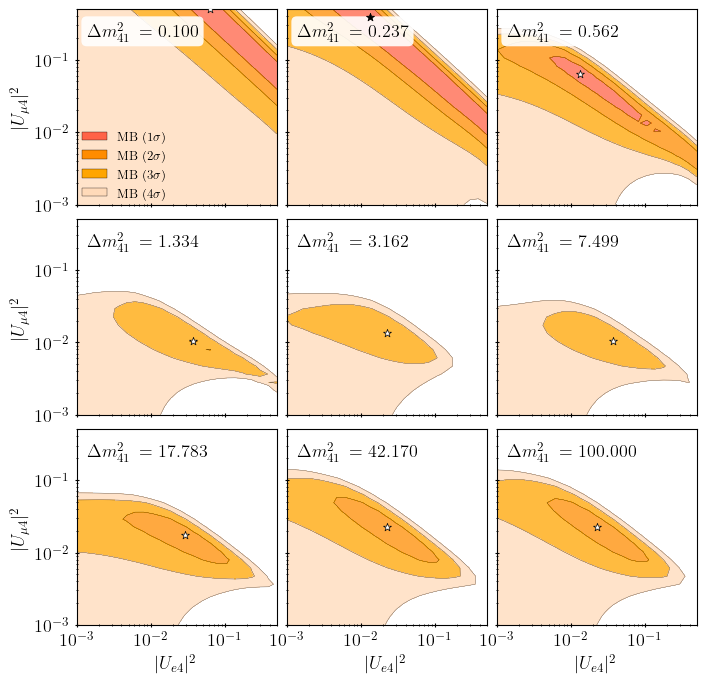

In [61]:
plot_all_slices('TZ_Mini_misid25', xi=2, yi=3, zi=1, global_deltachi2=True)